# Transferencia de calor
## Convección forzada externa sobre un cilindro en flujo cruzado
### Aplicación real en ingeniería mecánica

En una planta de procesos, una **tubería horizontal de acero** transporta un fluido caliente y atraviesa una zona donde se ha instalado un sistema de ventilación forzada para disminuir la temperatura superficial exterior y proteger al personal de contacto accidental.

La tubería se modela como un **cilindro largo en flujo cruzado**. Aire ambiente a **20 °C** y **1 atm** es impulsado perpendicularmente al eje de la tubería mediante un ventilador, con una velocidad uniforme de **8 m/s**.

La tubería tiene un **diámetro exterior** de $D=0.060\ \mathrm{m}$ y una **longitud expuesta al aire** de $L=4.0\ \mathrm{m}$. Durante operación estacionaria, la temperatura superficial exterior de la tubería se mantiene aproximadamente constante en $T_s=110\ ^\circ\mathrm{C}$.

Se desea estimar la tasa de pérdida de calor por convección desde la superficie exterior de la tubería hacia el aire. Además, se hará un **análisis paramétrico** para estudiar cómo cambian el coeficiente convectivo $h$ y la tasa de calor $\dot Q$ cuando varía la velocidad del aire.


## Objetivos

1. Calcular la **temperatura de película**.
2. Obtener con **CoolProp** las propiedades del aire a la temperatura de película.
3. Calcular $\nu$, $Pr$, $Re_D$, $Nu_D$, $h$, $A_s$ y $\dot Q$.
4. Graficar la variación de:
   - $h$ versus velocidad del aire.
   - $\dot Q$ versus velocidad del aire.
5. Interpretar los resultados desde el punto de vista del diseño térmico en ingeniería mecánica.


## Ecuaciones del problema

La temperatura de película es:

$$
T_f = \frac{T_s + T_\infty}{2}
$$

La viscosidad cinemática y el número de Prandtl se calculan como:

$$
\nu = \frac{\mu}{\rho}
$$

$$
Pr = \frac{\mu c_p}{k}
$$

El número de Reynolds para un cilindro en flujo cruzado es:

$$
Re_D = \frac{U_\infty D}{\nu}
$$

Usaremos la correlación de **Churchill y Bernstein**:

$$
Nu_D = 0.3 + \frac{0.62\,Re_D^{1/2}Pr^{1/3}}{\left[1+\left(0.4/Pr\right)^{2/3}\right]^{1/4}}
\left[1+\left(\frac{Re_D}{282000}\right)^{5/8}\right]^{4/5}
$$

Luego:

$$
h = \frac{Nu_D\,k}{D}
$$

El área lateral externa de la tubería es:

$$
A_s = \pi D L
$$

La tasa de pérdida de calor por convección es:

$$
\dot Q = h A_s (T_s - T_\infty)
$$


## Instalación de librerías

Si hace falta, instala CoolProp con:

```python
pip install CoolProp
```


In [1]:
from CoolProp.CoolProp import PropsSI
import math
import numpy as np
import matplotlib.pyplot as plt

## 1. Datos del problema

In [2]:
# Datos base
T_inf_C = 20.0       # °C
T_s_C   = 110.0      # °C
P       = 101325.0   # Pa
U       = 8.0        # m/s
D       = 0.060      # m
L       = 4.0        # m

# Conversión a Kelvin
T_inf = T_inf_C + 273.15
T_s   = T_s_C + 273.15

print(f"T_inf = {T_inf:.2f} K")
print(f"T_s   = {T_s:.2f} K")

T_inf = 293.15 K
T_s   = 383.15 K


## 2. Temperatura de película

In [3]:
T_f = 0.5 * (T_inf + T_s)
print(f"Temperatura de película = {T_f:.2f} K")
print(f"Temperatura de película = {T_f - 273.15:.2f} °C")

Temperatura de película = 338.15 K
Temperatura de película = 65.00 °C


## 3. Propiedades del aire con CoolProp

In [4]:
rho = PropsSI('D', 'T', T_f, 'P', P, 'Air')   # kg/m^3
mu  = PropsSI('V', 'T', T_f, 'P', P, 'Air')   # Pa.s
k   = PropsSI('L', 'T', T_f, 'P', P, 'Air')   # W/m.K
cp  = PropsSI('C', 'T', T_f, 'P', P, 'Air')   # J/kg.K

print("Propiedades del aire a T_f:")
print(f"rho = {rho:.6f} kg/m^3")
print(f"mu  = {mu:.6e} Pa·s")
print(f"k   = {k:.6f} W/m·K")
print(f"cp  = {cp:.2f} J/kg·K")

Propiedades del aire a T_f:
rho = 1.043930 kg/m^3
mu  = 2.032871e-05 Pa·s
k   = 0.029162 W/m·K
cp  = 1008.35 J/kg·K


## 4. Cálculo de propiedades derivadas

In [5]:
nu = mu / rho
Pr = mu * cp / k

print(f"nu = {nu:.6e} m^2/s")
print(f"Pr = {Pr:.6f}")

nu = 1.947325e-05 m^2/s
Pr = 0.702917


## 5. Cálculo para la velocidad base $U_\infty = 8\ \mathrm{m/s}$

In [6]:
Re_D = U * D / nu

Nu_D = 0.3 + (
    (0.62 * Re_D**0.5 * Pr**(1/3)) /
    ((1 + (0.4 / Pr)**(2/3))**0.25)
) * (1 + (Re_D / 282000)**(5/8))**(4/5)

h = Nu_D * k / D
A = math.pi * D * L
Q = h * A * (T_s - T_inf)
q_pp = Q / A

print("=== RESULTADOS CASO BASE ===")
print(f"Re_D = {Re_D:.6e}")
print(f"Nu_D = {Nu_D:.6f}")
print(f"h    = {h:.6f} W/m^2·K")
print(f"A_s  = {A:.6f} m^2")
print(f"Q    = {Q:.6f} W")
print(f"q''  = {q_pp:.6f} W/m^2")

=== RESULTADOS CASO BASE ===
Re_D = 2.464919e+04
Nu_D = 89.224464
h    = 43.366033 W/m^2·K
A_s  = 0.753982 m^2
Q    = 2942.749680 W
q''  = 3902.942983 W/m^2


## 6. Función para repetir el cálculo a cualquier velocidad

Esta función servirá para el análisis paramétrico.


In [7]:
def calcular_conveccion_cilindro(U, T_inf, T_s, P, D, L):
    T_f = 0.5 * (T_inf + T_s)

    rho = PropsSI('D', 'T', T_f, 'P', P, 'Air')
    mu  = PropsSI('V', 'T', T_f, 'P', P, 'Air')
    k   = PropsSI('L', 'T', T_f, 'P', P, 'Air')
    cp  = PropsSI('C', 'T', T_f, 'P', P, 'Air')

    nu = mu / rho
    Pr = mu * cp / k
    Re_D = U * D / nu

    Nu_D = 0.3 + (
        (0.62 * Re_D**0.5 * Pr**(1/3)) /
        ((1 + (0.4 / Pr)**(2/3))**0.25)
    ) * (1 + (Re_D / 282000)**(5/8))**(4/5)

    h = Nu_D * k / D
    A = math.pi * D * L
    Q = h * A * (T_s - T_inf)
    q_pp = Q / A

    return {
        "U": U,
        "T_f": T_f,
        "rho": rho,
        "mu": mu,
        "k": k,
        "cp": cp,
        "nu": nu,
        "Pr": Pr,
        "Re_D": Re_D,
        "Nu_D": Nu_D,
        "h": h,
        "A": A,
        "Q": Q,
        "q_pp": q_pp
    }

## 7. Análisis paramétrico con la velocidad del aire

Se evaluará el problema para velocidades entre **2 m/s** y **20 m/s**.


In [8]:
velocidades = np.linspace(2.0, 20.0, 30)

h_vals = []
Q_vals = []
Re_vals = []
Nu_vals = []

for Ui in velocidades:
    res = calcular_conveccion_cilindro(Ui, T_inf, T_s, P, D, L)
    h_vals.append(res["h"])
    Q_vals.append(res["Q"])
    Re_vals.append(res["Re_D"])
    Nu_vals.append(res["Nu_D"])

h_vals = np.array(h_vals)
Q_vals = np.array(Q_vals)
Re_vals = np.array(Re_vals)
Nu_vals = np.array(Nu_vals)

print("Análisis paramétrico completado.")

Análisis paramétrico completado.


## 8. Gráfica de $h$ versus velocidad del aire

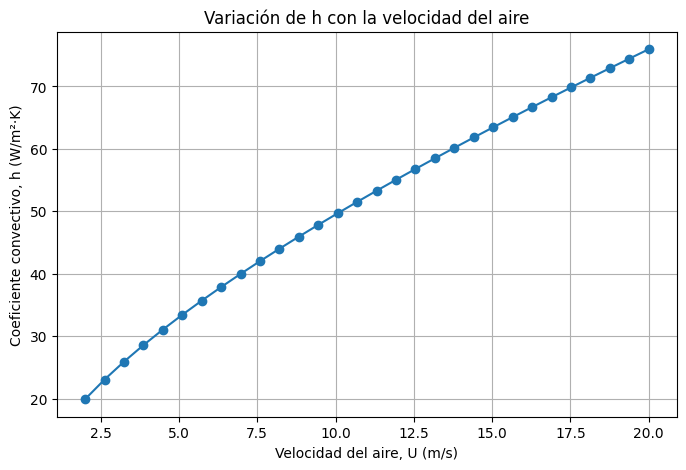

In [9]:
plt.figure(figsize=(8,5))
plt.plot(velocidades, h_vals, marker='o')
plt.xlabel("Velocidad del aire, U (m/s)")
plt.ylabel("Coeficiente convectivo, h (W/m²·K)")
plt.title("Variación de h con la velocidad del aire")
plt.grid(True)
plt.show()

## 9. Gráfica de $\dot Q$ versus velocidad del aire

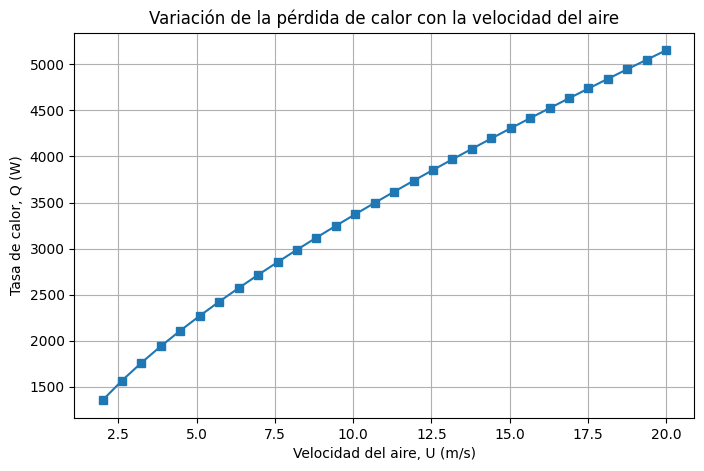

In [10]:
plt.figure(figsize=(8,5))
plt.plot(velocidades, Q_vals, marker='s')
plt.xlabel("Velocidad del aire, U (m/s)")
plt.ylabel("Tasa de calor, Q (W)")
plt.title("Variación de la pérdida de calor con la velocidad del aire")
plt.grid(True)
plt.show()

## 10. Tabla resumida para algunas velocidades seleccionadas

In [ ]:
velocidades_seleccionadas = [2, 4, 6, 8, 12, 16, 20]

print("   U (m/s) |        Re_D |       Nu_D |    h (W/m²·K) |        Q (W)")
print("-"*75)
for Ui in velocidades_seleccionadas:
    res = calcular_conveccion_cilindro(Ui, T_inf, T_s, P, D, L)
    print(f"{res['U']:10.2f} | {res['Re_D']:11.4e} | {res['Nu_D']:10.4f} | {res['h']:14.4f} | {res['Q']:12.4f}")

## 11. Discusión ingenieril

A partir de las gráficas, se puede observar que:

- al aumentar la velocidad del aire, aumenta el número de Reynolds;
- al aumentar $Re_D$, aumenta el número de Nusselt;
- al aumentar $Nu_D$, aumenta el coeficiente convectivo $h$;
- al aumentar $h$, también aumenta la tasa de pérdida de calor $\dot Q$.

Esto tiene una interpretación directa en ingeniería mecánica:

- un ventilador más intenso incrementa el enfriamiento de la tubería;
- la tubería pierde más energía al ambiente;
- el diseño del aislamiento térmico puede volverse más importante;
- las condiciones de seguridad superficial cambian con la ventilación.

En una planta industrial, este análisis sirve para estimar rápidamente el impacto de la ventilación forzada sobre tuberías calientes, líneas de vapor, ductos de gases o intercambiadores sencillos expuestos al ambiente.


## 12. Ejercicio adicional sugerido para estudiantes

Modificar el notebook para estudiar uno o más de los siguientes casos:

1. Cambiar la temperatura superficial a $65\ ^\circ\mathrm{C}$.
2. Comparar dos diámetros: $D=0.03\ \mathrm{m}$ y $D=0.10\ \mathrm{m}$.
3. Mantener velocidad fija y variar la temperatura ambiente.
4. Graficar también $Nu_D$ y $Re_D$ versus la velocidad.

Con eso se puede enriquecer el análisis de diseño térmico.
